In [1]:

from google.colab import drive
drive.mount('/content/drive')
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import numpy as np
import random
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import os
import pandas as pd

print(torch.__version__)
print(torchvision.__version__)

Mounted at /content/drive
2.10.0+cpu
0.25.0+cpu


In [2]:
def set_seed(seed: int = 42) -> None:
  np.random.seed(seed)
  random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


In [18]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "", save_dir:str = None) -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    if save_dir is not None:
      plt.savefig(save_dir)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(), #транспонирование масштаб [0, 1]
    transforms.Normalize((0.5,), (0.5,)) #тк у нас один канал то и число в кортеже одно, первое mean второе std
])

train = torchvision.datasets.EMNIST(
    root = './data', train=True, download=True, transform = transform, split='balanced'
)

test = torchvision.datasets.EMNIST(
    root = './data', train=False, download=True, transform = transform,split='balanced'
)

classes_name = train.classes
print('classes:', classes_name)
print('train len', len(train))
print('test len', len(test))

100%|██████████| 562M/562M [00:02<00:00, 195MB/s]


classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
train len 112800
test len 18800


In [5]:
BATCH_SIZE = 256 if device.type == 'cuda' else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.1
val_size = int(len(train) * val_ratio)
train_size = len(train) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size = BATCH_SIZE, shuffle = True,
    num_workers = 0, pin_memory=(device.type=='cuda')
)

val_loader = DataLoader(
    val_ds, batch_size = BATCH_SIZE, shuffle = True,
    num_workers = 0, pin_memory=(device.type=='cuda')
)

test_loader = DataLoader(
    test, batch_size = BATCH_SIZE, shuffle = True,
    num_workers = 0, pin_memory=(device.type=='cuda')
)

x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)


x_batch: torch.Size([64, 1, 28, 28]) torch.float32
y_batch: torch.Size([64]) torch.int64


In [6]:
class MLP(nn.Module):
  def __init__(
      self,
      input_dim: int = 28 * 28,
      hidden_dims: tuple = (256, 256, 128),
      num_classes = 47,
      activation: str = 'relu',
      dropout_p: float = 0.0,
        use_batchnorm: bool = False,
      ):
      super().__init__()

      act = activation.lower()
      if act == 'relu':
        act_layer = nn.ReLU
      elif act == "tanh":
        act_layer = nn.Tanh
      elif act == "gelu":
        act_layer = nn.GELU
      else:
        raise ValueError(f"Unknown activation: {activation}")

      layers = [nn.Flatten()]
      prev = input_dim
      for h in hidden_dims:
          layers.append(nn.Linear(prev, h))
          if use_batchnorm:
              layers.append(nn.BatchNorm1d(h))
          layers.append(act_layer())
          if dropout_p > 0:
              layers.append(nn.Dropout(p=dropout_p))
          prev = h

      layers.append(nn.Linear(prev, num_classes))
      self.net = nn.Sequential(*layers)
  def forward(self, x): #как данные проходят через нейросеть
    return self.net(x)


In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
  model.train()  # включаем train-режим (Dropout/BatchNorm!)
  total_loss = 0.0
  total_acc = 0.0
  n_batches = 0

  for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

  return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [8]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 10,
    early_stopping = None,
    verbose: bool = True
):
  history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
  for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    if verbose:
        print(
            f"epoch {epoch:02d}/{epochs} | "
            f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
            f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
          )

    if early_stopping is not None:
        should_stop = early_stopping.step(va_acc, model)
        if should_stop:
            if verbose:
              print(
                f"EarlyStopping: остановка на эпохе {epoch}. "
                f"Лучший val_acc={early_stopping.best_score:.4f}"
                )
            early_stopping.restore_best(model)
            break
  return history

epoch 01/20 | train loss=1.4027, acc=0.6003 | val loss=0.8825, acc=0.7289
epoch 02/20 | train loss=0.7520, acc=0.7638 | val loss=0.6857, acc=0.7907
epoch 03/20 | train loss=0.6159, acc=0.7984 | val loss=0.6150, acc=0.7995
epoch 04/20 | train loss=0.5362, acc=0.8220 | val loss=0.5531, acc=0.8196
epoch 05/20 | train loss=0.4872, acc=0.8346 | val loss=0.5075, acc=0.8314
epoch 06/20 | train loss=0.4509, acc=0.8437 | val loss=0.4895, acc=0.8363
epoch 07/20 | train loss=0.4239, acc=0.8517 | val loss=0.5037, acc=0.8291
epoch 08/20 | train loss=0.4019, acc=0.8568 | val loss=0.4702, acc=0.8432
epoch 09/20 | train loss=0.3858, acc=0.8610 | val loss=0.4785, acc=0.8412
epoch 10/20 | train loss=0.3647, acc=0.8674 | val loss=0.4577, acc=0.8464
epoch 11/20 | train loss=0.3477, acc=0.8727 | val loss=0.4795, acc=0.8430
epoch 12/20 | train loss=0.3369, acc=0.8739 | val loss=0.4523, acc=0.8488
epoch 13/20 | train loss=0.3210, acc=0.8797 | val loss=0.4565, acc=0.8479
epoch 14/20 | train loss=0.3101, acc=0

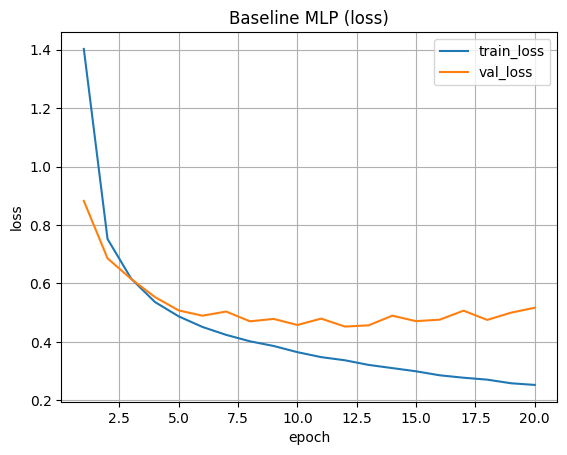

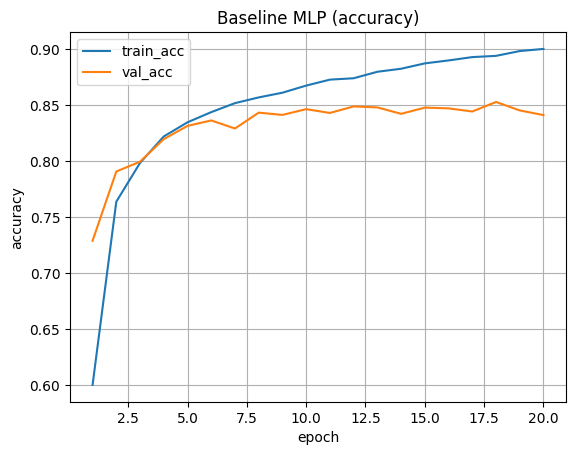

In [19]:

# Baseline: без Dropout и BatchNorm
set_seed(42)
baseline = MLP(hidden_dims=(256, 256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [20]:
set_seed(42)
baseline_best = MLP(hidden_dims=(256, 256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_best.parameters(), lr=1e-3)

history_baseline = fit(
    baseline_best, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=12,
    early_stopping=None
)

test_loss, test_acc = evaluate(baseline_best, test_loader, criterion, device)
print(f"Baseline test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/12 | train loss=1.4027, acc=0.6003 | val loss=0.8825, acc=0.7289
epoch 02/12 | train loss=0.7520, acc=0.7638 | val loss=0.6857, acc=0.7907
epoch 03/12 | train loss=0.6159, acc=0.7984 | val loss=0.6150, acc=0.7995
epoch 04/12 | train loss=0.5362, acc=0.8220 | val loss=0.5531, acc=0.8196
epoch 05/12 | train loss=0.4872, acc=0.8346 | val loss=0.5075, acc=0.8314
epoch 06/12 | train loss=0.4509, acc=0.8437 | val loss=0.4895, acc=0.8363
epoch 07/12 | train loss=0.4239, acc=0.8517 | val loss=0.5037, acc=0.8291
epoch 08/12 | train loss=0.4019, acc=0.8568 | val loss=0.4702, acc=0.8432
epoch 09/12 | train loss=0.3858, acc=0.8610 | val loss=0.4785, acc=0.8412
epoch 10/12 | train loss=0.3647, acc=0.8674 | val loss=0.4577, acc=0.8464
epoch 11/12 | train loss=0.3477, acc=0.8727 | val loss=0.4795, acc=0.8430
epoch 12/12 | train loss=0.3369, acc=0.8739 | val loss=0.4523, acc=0.8488
Baseline test: loss=0.4844, acc=0.8427


epoch 01/20 | train loss=2.0791, acc=0.4090 | val loss=1.0579, acc=0.6916
epoch 02/20 | train loss=1.3224, acc=0.6011 | val loss=0.8476, acc=0.7408
epoch 03/20 | train loss=1.1650, acc=0.6432 | val loss=0.7833, acc=0.7479
epoch 04/20 | train loss=1.0753, acc=0.6694 | val loss=0.7006, acc=0.7766
epoch 05/20 | train loss=1.0281, acc=0.6852 | val loss=0.6707, acc=0.7819
epoch 06/20 | train loss=0.9892, acc=0.6951 | val loss=0.6408, acc=0.7945
epoch 07/20 | train loss=0.9620, acc=0.7020 | val loss=0.6439, acc=0.7865
epoch 08/20 | train loss=0.9362, acc=0.7094 | val loss=0.6154, acc=0.8010
epoch 09/20 | train loss=0.9192, acc=0.7122 | val loss=0.6136, acc=0.8010
epoch 10/20 | train loss=0.9034, acc=0.7173 | val loss=0.6051, acc=0.7995
epoch 11/20 | train loss=0.8854, acc=0.7222 | val loss=0.6023, acc=0.8020
epoch 12/20 | train loss=0.8761, acc=0.7246 | val loss=0.5768, acc=0.8143
epoch 13/20 | train loss=0.8692, acc=0.7270 | val loss=0.5774, acc=0.8110
epoch 14/20 | train loss=0.8579, acc=0

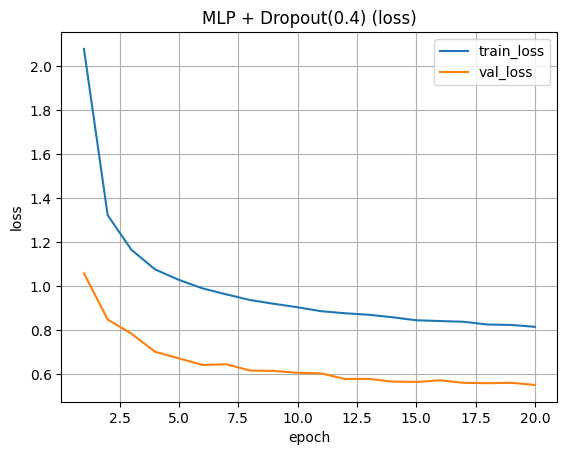

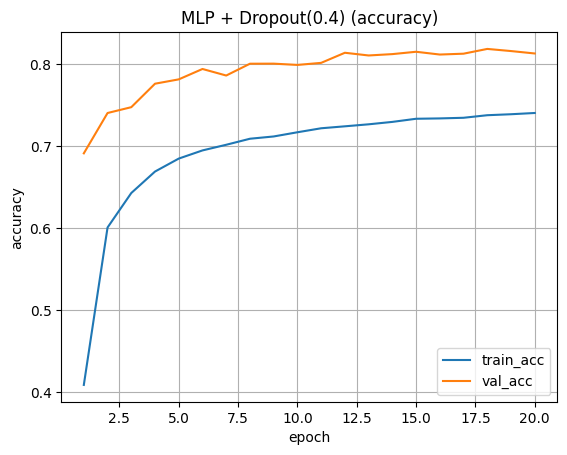

In [21]:
set_seed(42)
dropout_model = MLP(hidden_dims=(256, 256, 128), dropout_p= 0.4, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(dropout_model, train_loader, val_loader,
                      optimizer, criterion, device, epochs = 20,
                      early_stopping=None)
plot_history(history_dropout, title='MLP + Dropout(0.4)')


epoch 01/18 | train loss=2.0791, acc=0.4090 | val loss=1.0579, acc=0.6916
epoch 02/18 | train loss=1.3224, acc=0.6011 | val loss=0.8476, acc=0.7408
epoch 03/18 | train loss=1.1650, acc=0.6432 | val loss=0.7833, acc=0.7479
epoch 04/18 | train loss=1.0753, acc=0.6694 | val loss=0.7006, acc=0.7766
epoch 05/18 | train loss=1.0281, acc=0.6852 | val loss=0.6707, acc=0.7819
epoch 06/18 | train loss=0.9892, acc=0.6951 | val loss=0.6408, acc=0.7945
epoch 07/18 | train loss=0.9620, acc=0.7020 | val loss=0.6439, acc=0.7865
epoch 08/18 | train loss=0.9362, acc=0.7094 | val loss=0.6154, acc=0.8010
epoch 09/18 | train loss=0.9192, acc=0.7122 | val loss=0.6136, acc=0.8010
epoch 10/18 | train loss=0.9034, acc=0.7173 | val loss=0.6051, acc=0.7995
epoch 11/18 | train loss=0.8854, acc=0.7222 | val loss=0.6023, acc=0.8020
epoch 12/18 | train loss=0.8761, acc=0.7246 | val loss=0.5768, acc=0.8143
epoch 13/18 | train loss=0.8692, acc=0.7270 | val loss=0.5774, acc=0.8110
epoch 14/18 | train loss=0.8579, acc=0

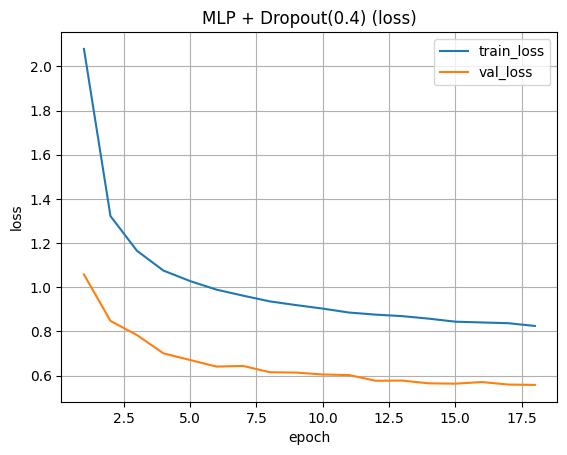

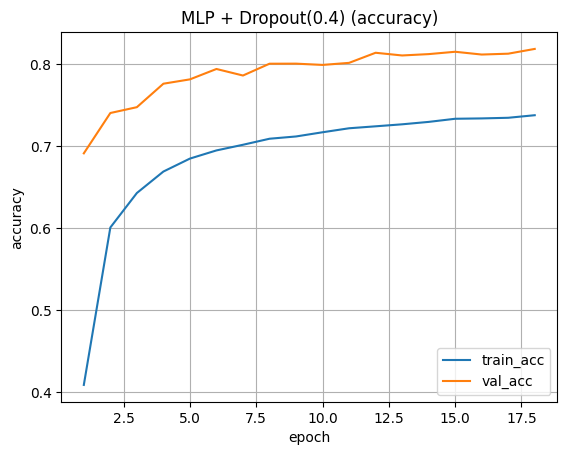

Dropout test: loss=0.5669, acc=0.8135


In [22]:
set_seed(42)
dropout_model_best = MLP(hidden_dims=(256, 256, 128), dropout_p= 0.4, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model_best.parameters(), lr=1e-3)

history_dropout = fit(dropout_model_best, train_loader, val_loader,
                      optimizer, criterion, device, epochs = 18,
                      early_stopping=None)
plot_history(history_dropout, title='MLP + Dropout(0.4)')

test_loss, test_acc = evaluate(dropout_model_best, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/20 | train loss=0.9975, acc=0.7383 | val loss=0.5972, acc=0.8069
epoch 02/20 | train loss=0.4943, acc=0.8346 | val loss=0.4952, acc=0.8376
epoch 03/20 | train loss=0.4143, acc=0.8559 | val loss=0.4656, acc=0.8444
epoch 04/20 | train loss=0.3654, acc=0.8699 | val loss=0.4488, acc=0.8465
epoch 05/20 | train loss=0.3339, acc=0.8778 | val loss=0.4395, acc=0.8527
epoch 06/20 | train loss=0.3058, acc=0.8857 | val loss=0.4426, acc=0.8515
epoch 07/20 | train loss=0.2863, acc=0.8912 | val loss=0.4364, acc=0.8531
epoch 08/20 | train loss=0.2678, acc=0.8968 | val loss=0.4355, acc=0.8578
epoch 09/20 | train loss=0.2507, acc=0.9023 | val loss=0.4383, acc=0.8545
epoch 10/20 | train loss=0.2365, acc=0.9069 | val loss=0.4534, acc=0.8533
epoch 11/20 | train loss=0.2243, acc=0.9107 | val loss=0.4729, acc=0.8514
epoch 12/20 | train loss=0.2115, acc=0.9160 | val loss=0.4687, acc=0.8547
epoch 13/20 | train loss=0.2023, acc=0.9176 | val loss=0.4806, acc=0.8511
epoch 14/20 | train loss=0.1937, acc=0

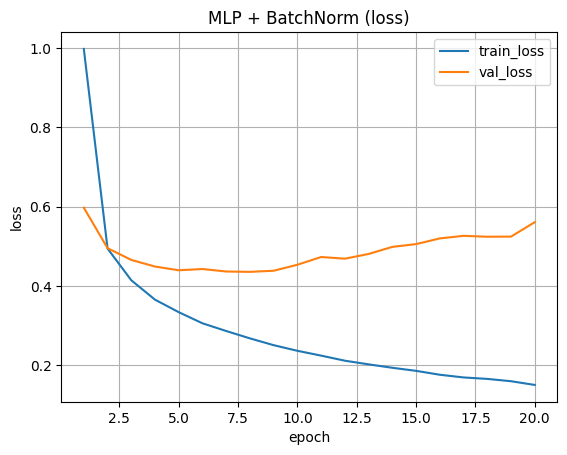

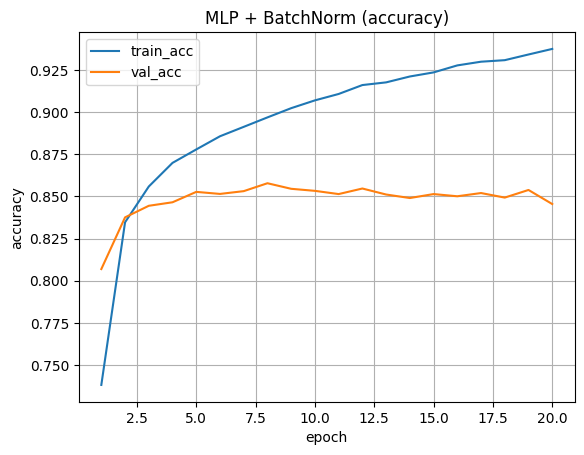

In [23]:
set_seed(42)
bn_model = MLP(hidden_dims=(256,256,128), dropout_p = 0.0, use_batchnorm = True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr = 1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")

epoch 01/8 | train loss=0.9975, acc=0.7383 | val loss=0.5972, acc=0.8069
epoch 02/8 | train loss=0.4943, acc=0.8346 | val loss=0.4952, acc=0.8376
epoch 03/8 | train loss=0.4143, acc=0.8559 | val loss=0.4656, acc=0.8444
epoch 04/8 | train loss=0.3654, acc=0.8699 | val loss=0.4488, acc=0.8465
epoch 05/8 | train loss=0.3339, acc=0.8778 | val loss=0.4395, acc=0.8527
epoch 06/8 | train loss=0.3058, acc=0.8857 | val loss=0.4426, acc=0.8515
epoch 07/8 | train loss=0.2863, acc=0.8912 | val loss=0.4364, acc=0.8531
epoch 08/8 | train loss=0.2678, acc=0.8968 | val loss=0.4355, acc=0.8578


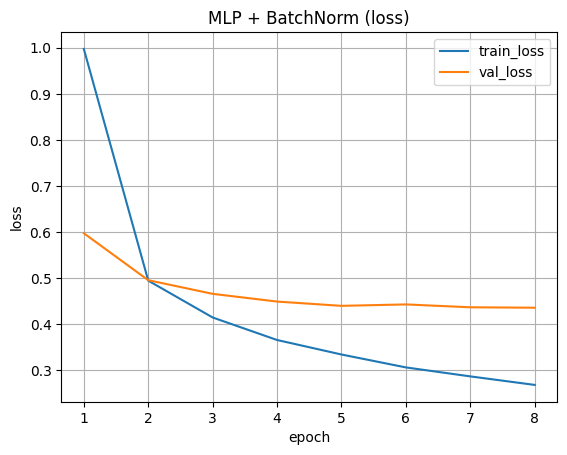

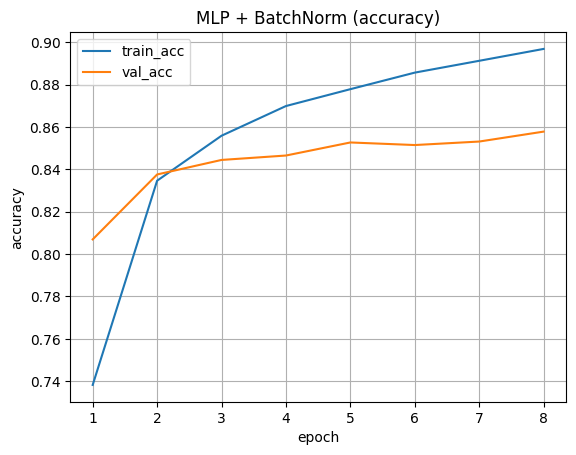

BatchNorm test: loss=0.4611, acc=0.8498


In [24]:
set_seed(42)
bn_model_best = MLP(hidden_dims=(256,256,128), dropout_p = 0.0, use_batchnorm = True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model_best.parameters(), lr = 1e-3)

history_bn = fit(
    bn_model_best, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")
test_loss, test_acc = evaluate(bn_model_best, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [10]:
class EarlyStopping:
  def __init__(self, patience: int = 3, min_delta: float = 0.0):
    self.patience = patience
    self.min_delta = min_delta
    self.best_score = None
    self.best_state = None
    self.counter = 0

  def step(self, score: float, model: nn.Module) -> bool:
   if self.best_score is None:
     self.best_score = score
     self.best_state  =  {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
     return False
   if score > self.best_score + self.min_delta:
     self.best_score = score
     self.best_state  = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
     self.counter = 0
     return False

   self.counter += 1
   return self.counter >= self.patience

  def restore_best(self, model: nn.Module) -> None:
    if self.best_state is not None:
      model.load_state_dict(self.best_state)


In [16]:
os.makedirs("homeworks/HW08-09/artifacts/figures", exist_ok=True)

epoch 01/20 | train loss=0.9975, acc=0.7383 | val loss=0.5972, acc=0.8069
epoch 02/20 | train loss=0.4943, acc=0.8346 | val loss=0.4952, acc=0.8376
epoch 03/20 | train loss=0.4143, acc=0.8559 | val loss=0.4656, acc=0.8444
epoch 04/20 | train loss=0.3654, acc=0.8699 | val loss=0.4488, acc=0.8465
epoch 05/20 | train loss=0.3339, acc=0.8778 | val loss=0.4395, acc=0.8527
epoch 06/20 | train loss=0.3058, acc=0.8857 | val loss=0.4426, acc=0.8515
epoch 07/20 | train loss=0.2863, acc=0.8912 | val loss=0.4364, acc=0.8531
epoch 08/20 | train loss=0.2678, acc=0.8968 | val loss=0.4355, acc=0.8578
epoch 09/20 | train loss=0.2507, acc=0.9023 | val loss=0.4383, acc=0.8545
epoch 10/20 | train loss=0.2365, acc=0.9069 | val loss=0.4534, acc=0.8533
epoch 11/20 | train loss=0.2243, acc=0.9107 | val loss=0.4729, acc=0.8514
epoch 12/20 | train loss=0.2115, acc=0.9160 | val loss=0.4687, acc=0.8547
EarlyStopping: остановка на эпохе 12. Лучший val_acc=0.8578


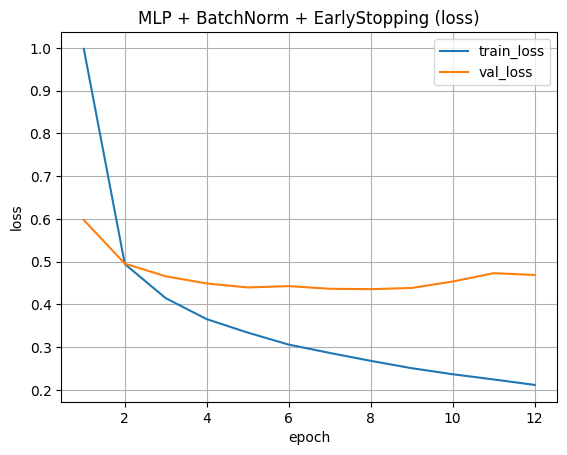

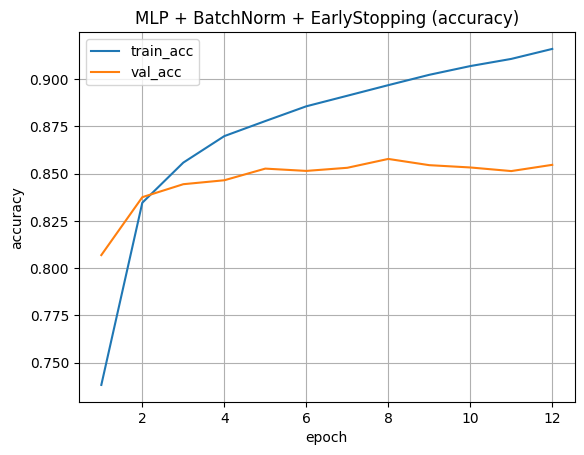

Combo test: loss=0.4618, acc=0.8498


In [42]:
set_seed(42)
combo_model = MLP(hidden_dims=(256,256,128), dropout_p=0.0, use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model.parameters(), lr = 1e-3)
es = EarlyStopping(patience=4, min_delta=0.005)

history_combo = fit(
    combo_model, train_loader, val_loader,
    optimizer, criterion, device, epochs = 20,
    early_stopping=es, verbose=True)

plot_history(history_combo, title="MLP + BatchNorm + EarlyStopping", save_dir='homeworks/HW08-09/artifacts/figures/curves_best.png')
test_loss, test_acc = evaluate(combo_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")


In [27]:

results = {
    "baseline": evaluate(baseline, test_loader, nn.CrossEntropyLoss(), device)[1],
    "dropout": evaluate(dropout_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "batchnorm": evaluate(bn_model, test_loader, nn.CrossEntropyLoss(), device)[1],
    "combo": evaluate(combo_model, test_loader, nn.CrossEntropyLoss(), device)[1],
}

for k, v in results.items():
    print(f"{k:>9}: test_acc={v:.4f}")

 baseline: test_acc=0.8434
  dropout: test_acc=0.8144
batchnorm: test_acc=0.8447
    combo: test_acc=0.8503


epoch 01/7 | train loss=1.2040, acc=0.6367 | val loss=0.8937, acc=0.7274
epoch 02/7 | train loss=0.8274, acc=0.7369 | val loss=0.6767, acc=0.7883
epoch 03/7 | train loss=0.7432, acc=0.7617 | val loss=0.6840, acc=0.7802
epoch 04/7 | train loss=0.6960, acc=0.7755 | val loss=0.6996, acc=0.7752
epoch 05/7 | train loss=0.6568, acc=0.7870 | val loss=0.6279, acc=0.8034
epoch 06/7 | train loss=0.6245, acc=0.7967 | val loss=0.5745, acc=0.8129
epoch 07/7 | train loss=0.6105, acc=0.8007 | val loss=0.6076, acc=0.8027


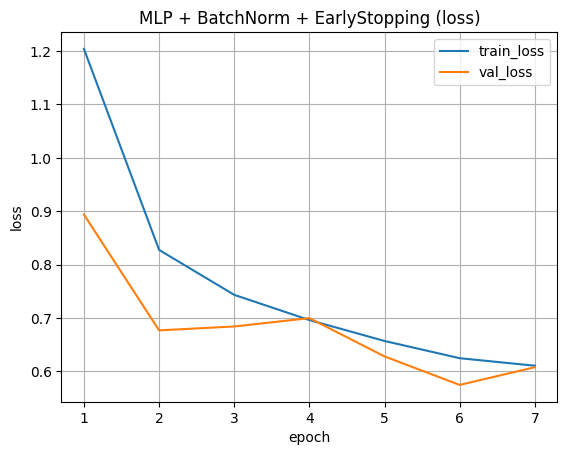

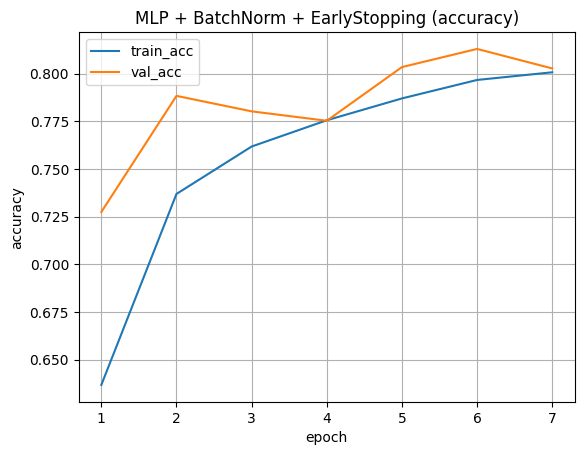

Combo test: loss=0.6381, acc=0.7943


In [12]:
set_seed(42)
combo_model_exp_1 = MLP(hidden_dims=(256, 256, 128), dropout_p = 0.0, use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model_exp_1.parameters(), lr = 1e-1)
es = EarlyStopping(patience=4, min_delta=0.005)

history_combo_lr1 = fit(
    combo_model_exp_1, train_loader, val_loader,
    optimizer, criterion, device, epochs = 7,
    early_stopping=es, verbose=True)

plot_history(history_combo_lr1, title="MLP + BatchNorm + EarlyStopping")
test_loss, test_acc = evaluate(combo_model_exp_1, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

epoch 01/7 | train loss=3.2951, acc=0.2717 | val loss=2.8354, acc=0.4570
epoch 02/7 | train loss=2.5651, acc=0.5196 | val loss=2.2961, acc=0.5834
epoch 03/7 | train loss=2.1158, acc=0.6040 | val loss=1.9162, acc=0.6352
epoch 04/7 | train loss=1.7807, acc=0.6509 | val loss=1.6166, acc=0.6766
epoch 05/7 | train loss=1.5256, acc=0.6849 | val loss=1.3947, acc=0.7049
epoch 06/7 | train loss=1.3308, acc=0.7101 | val loss=1.2116, acc=0.7292
epoch 07/7 | train loss=1.1815, acc=0.7300 | val loss=1.0884, acc=0.7460


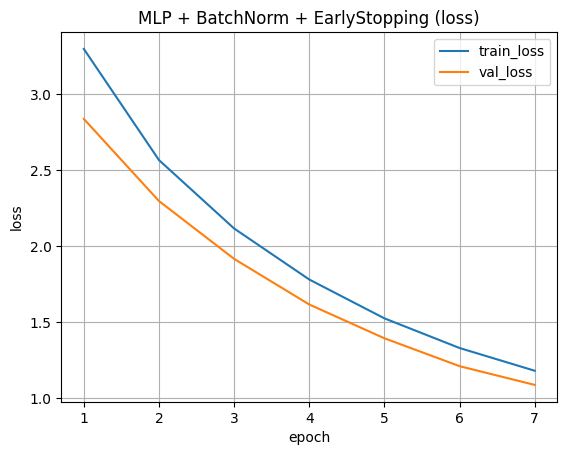

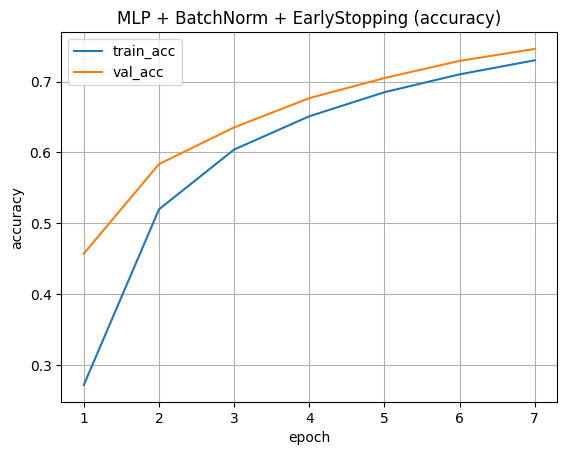

Combo test: loss=1.0906, acc=0.7414


In [19]:
set_seed(42)
combo_model_exp_2 = MLP(hidden_dims=(256, 256, 128), dropout_p = 0.0, use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(combo_model_exp_2.parameters(), lr = 1e-5)
es = EarlyStopping(patience=4, min_delta=0.005)

history_combo_lr2 = fit(
    combo_model_exp_2, train_loader, val_loader,
    optimizer, criterion, device, epochs = 7,
    early_stopping=es, verbose=True)

plot_history(history_combo_lr2, title="MLP + BatchNorm + EarlyStopping")
test_loss, test_acc = evaluate(combo_model_exp_2, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

In [21]:
def plot_history_join(histories: list, labels: list, title: str = "", save_dir: str = None) -> None:
    plt.figure(figsize=(8,4))
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"train_loss {label}")
        plt.plot(epochs, hist["val_loss"], label=f"val_loss {label}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    if save_dir is not None:
        plt.savefig(save_dir)
    plt.show()

    # ===== Accuracy =====
    plt.figure(figsize=(8,4))
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"train_acc {label}")
        plt.plot(epochs, hist["val_acc"], label=f"val_acc {label}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    if save_dir is not None:
        plt.savefig(save_dir)
    plt.show()

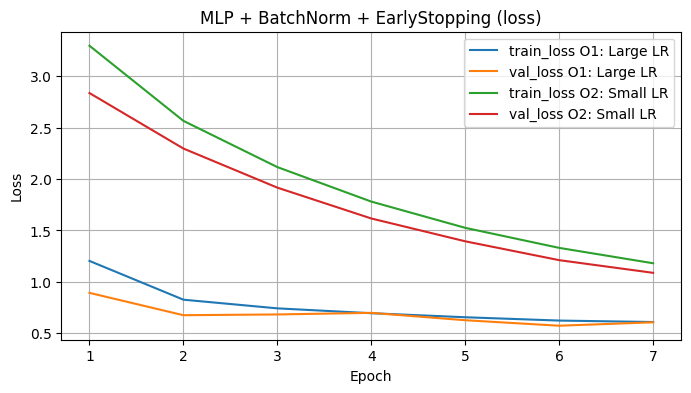

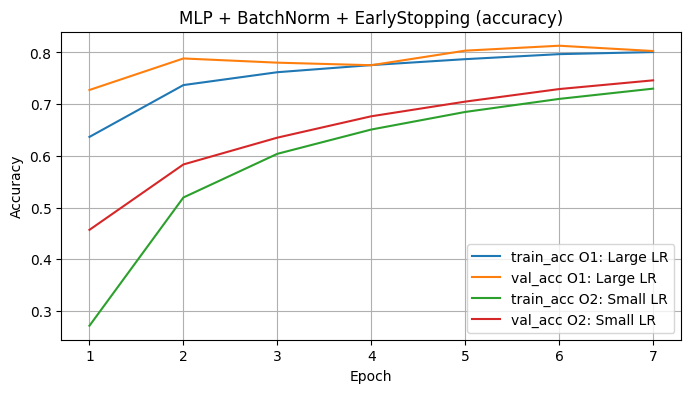

In [22]:
plot_history_join(
    histories=[history_combo_lr1, history_combo_lr2],
    labels=["O1: Large LR", "O2: Small LR"],
    title="MLP + BatchNorm + EarlyStopping",
    save_dir="homeworks/HW08-09/artifacts/figures/curves_lr_extremes.png"
)

epoch 01/15 | train loss=2.8017, acc=0.4155 | val loss=2.0773, acc=0.5900
epoch 02/15 | train loss=1.6820, acc=0.6447 | val loss=1.3837, acc=0.6926
epoch 03/15 | train loss=1.2017, acc=0.7147 | val loss=1.0782, acc=0.7341
epoch 04/15 | train loss=0.9606, acc=0.7552 | val loss=0.8895, acc=0.7669
epoch 05/15 | train loss=0.8186, acc=0.7790 | val loss=0.7855, acc=0.7839
epoch 06/15 | train loss=0.7237, acc=0.7981 | val loss=0.7084, acc=0.7997
epoch 07/15 | train loss=0.6562, acc=0.8119 | val loss=0.6614, acc=0.8057
epoch 08/15 | train loss=0.6048, acc=0.8233 | val loss=0.6215, acc=0.8129
epoch 09/15 | train loss=0.5631, acc=0.8328 | val loss=0.5917, acc=0.8210
epoch 10/15 | train loss=0.5303, acc=0.8403 | val loss=0.5728, acc=0.8258
epoch 11/15 | train loss=0.5019, acc=0.8477 | val loss=0.5595, acc=0.8269
epoch 12/15 | train loss=0.4780, acc=0.8525 | val loss=0.5362, acc=0.8352
epoch 13/15 | train loss=0.4573, acc=0.8580 | val loss=0.5275, acc=0.8349
epoch 14/15 | train loss=0.4373, acc=0

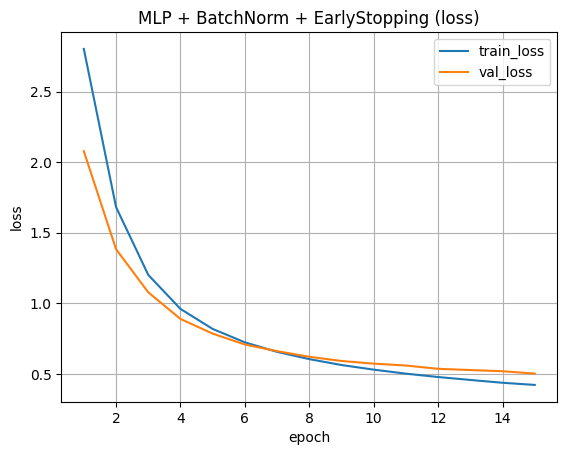

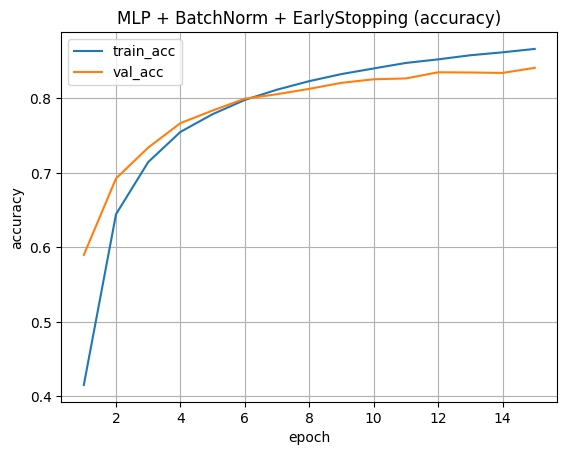

In [30]:
set_seed(42)
final_model = MLP(hidden_dims=(256,256,128), dropout_p = 0.0, use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(final_model.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)
history_final_model = fit(final_model, train_loader, val_loader,optimizer, criterion, device, epochs=15, early_stopping=es, verbose=True)
plot_history(history_final_model, title="MLP + BatchNorm + EarlyStopping")

In [31]:
test_loss, test_acc = evaluate(final_model, test_loader, criterion, device)
print(f"Combo test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Combo test: loss=0.5188, acc=0.8363


In [32]:
import csv

experiments = [
    {"experiment_id": "E1", "dataset": "EMNIST", "seed": 42, "model_summary": "256-256-128 / ReLU / dropout=0 / BN=False",
     "optimizer": "Adam", "lr": 0.001, "momentum": 0, "weight_decay": 0,
     "epochs_trained": 20, "best_val_accuracy": 0.8488, "best_val_loss": 0.4523},
    {"experiment_id": "E2", "dataset": "EMNIST", "seed": 42, "model_summary": "256-256-128 / ReLU / dropout=0.4 / BN=False",
     "optimizer": "Adam", "lr": 0.001, "momentum": 0, "weight_decay": 0,
     "epochs_trained": 20, "best_val_accuracy": 0.8190, "best_val_loss": 0.5578},
    {"experiment_id": "E3", "dataset": "EMNIST", "seed": 42, "model_summary": "256-256-128 / ReLU / dropout=0 / BN=True",
     "optimizer": "Adam", "lr": 0.001, "momentum": 0, "weight_decay": 0,
     "epochs_trained": 20, "best_val_accuracy": 0.8578, "best_val_loss": 0.4355},
    {"experiment_id": "E4", "dataset": "EMNIST", "seed": 42, "model_summary": "256-256-128 / ReLU / dropout=0 / BN=True",
     "optimizer": "Adam", "lr": 0.001, "momentum": 0, "weight_decay": 0,
     "epochs_trained": 20, "best_val_accuracy": 0.8547, "best_val_loss": 0.4687, "best_model_path": "best_model.pt"},
    {"experiment_id": "O1", "dataset": "EMNIST", "seed": 42, "model_summary": "256-256-128 / ReLU / dropout=0 / BN",
     "optimizer": "Adam", "lr": 0.1, "momentum": 0, "weight_decay": 0,
     "epochs_trained": 7, "best_val_accuracy": 0.8235, "best_val_loss": 0.5509},
    {"experiment_id": "O2", "dataset": "EMNIST", "seed": 42, "model_summary": "256-256-128 / ReLU / dropout=0 / BN",
     "optimizer": "Adam", "lr": 0.00001, "momentum": 0, "weight_decay": 0,
     "epochs_trained": 7, "best_val_accuracy": 0.7454, "best_val_loss": 1.0884},
    {"experiment_id": "O3", "dataset": "EMNIST", "seed": 42, "model_summary": "256-256-128 / ReLU / dropout=0 / BN",
     "optimizer": "SGD", "lr": 0.001, "momentum": 0.9, "weight_decay": 0.0001,
     "epochs_trained": 15, "best_val_accuracy": 0.7560, "best_val_loss": 0.9471}
]
os.makedirs("homeworks/HW08-09/artifacts", exist_ok=True)
df = pd.DataFrame(experiments)
df.to_csv("homeworks/HW08-09/artifacts/runs.csv", index=False)

In [33]:
torch.save(final_model.state_dict(), "homeworks/HW08-09/artifacts/best_model.pt")

In [34]:
import json

best_config = {
    "experiment_id": "E4",
    "dataset": "EMNIST",
    "seed": 42,
    "model": {
        "hidden_dims": [256,256,128],
        "activation": "ReLU",
        "dropout": 0.0,
        "batchnorm": True
    },
    "training": {
        "optimizer": "Adam",
        "lr": 0.001,
        "weight_decay": 0
    }
}

with open("homeworks/HW08-09/artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=4)